## **Part A**

In [26]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('/Users/lucasben/Documents/mba-business-analytics/courses/predictive-modelling/dataset_lm.csv')
df.head(5)

,Dependent Var,Explanatory Var #1,Explanatory Var #2,Explanatory Var #3,Explanatory Var #4,Explanatory Var #5,Explanatory Var #6,Explanatory Var #7,Explanatory Var #8,Explanatory Var #9,Explanatory Var #10,Explanatory Var #11,Explanatory Var #12,Explanatory Var #13,Explanatory Var #14,Explanatory Var #15
0,56.293458,13.698667,50.639873,0,-18.568035,45.121911,11.412501,56.410757,2,-12.281132,38.996909,-3.010548,49.195073,0,-21.153143,46.919314
1,58.473431,2.714725,65.845845,1,-25.105932,47.190213,10.080280,65.383107,3,-36.763585,51.654939,4.991111,45.591729,0,-6.474403,53.383508
2,94.195330,11.618072,65.072497,0,-7.897464,52.163036,11.057301,82.812717,0,-15.733547,48.913837,-2.457696,56.608806,0,-27.903299,48.515026
3,29.074583,0.818623,45.408996,1,-18.316132,54.356714,5.029029,48.812471,1,-12.825591,45.851732,14.974177,47.362594,1,-10.064411,55.266254
4,86.035569,9.077544,73.548021,0,-19.204165,47.186807,12.128134,62.520911,2,-13.804860,47.765904,9.593982,53.700562,0,-17.546302,48.150543


In [3]:
df.isna().sum()

Dependent Var          0
Explanatory Var #1     0
Explanatory Var #2     0
Explanatory Var #3     0
Explanatory Var #4     0
Explanatory Var #5     0
Explanatory Var #6     0
Explanatory Var #7     0
Explanatory Var #8     0
Explanatory Var #9     0
Explanatory Var #10    0
Explanatory Var #11    0
Explanatory Var #12    0
Explanatory Var #13    0
Explanatory Var #14    0
Explanatory Var #15    0
dtype: int64

In [4]:
X = df.drop('Dependent Var', axis=1)
y = df['Dependent Var']
X = sm.add_constant(X) # adding intercept term

In [20]:
model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.578e+30
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        15:05:03   Log-Likelihood:                 12180.
No. Observations:                 422   AIC:                        -2.433e+04
Df Residuals:                     406   BIC:                        -2.426e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.0000    6.3e-14   5.08e+14      0.000      32.000      32.000
Explanatory Var #1      1.3000   5.09e-16   2.56e+15      0.000       1.300       1.300
Explanatory Var #2      1.7000    3.7e-16    4.6e+15      0.000       1.700       1.700
Explanatory Var #3      6.2000   7.09e-15   8.74e+14      0.000       6.200       6.200
Explanatory Var #4      2.1000   4.37e-16   4.81e+15      0.000       2.100       2.100
Explanatory Var #5     -0.9000   5.12e-16  -1.76e+15      0.000      -0.900      -0.900
Explanatory Var #6  -3.636e-15   3.09e-16    -11.770      0.000   -4.24e-15   -3.03e-15
Explanatory Var #7  -8.674e-16   2.39e-16     -3.634      0.000   -1.34e-15   -3.98e-16
Explanatory Var #8  -5.218e-15   3.24e-15     -1.609      0.108   -1.16e-14    1.16e-15
Explanatory Var #9   3.187e-15   4.15e-16      7.685      0.000    2.37e-15       4e-15
Explanatory Var #10 -1.193e-15   5.17e-16     -2.309      0.021   -2.21e-15   -1.77e-16
Explanatory Var #11  3.962e-15      5e-16      7.927      0.000    2.98e-15    4.94e-15
Explanatory Var #12  5.829e-16   3.74e-16      1.559      0.120   -1.52e-16    1.32e-15
Explanatory Var #13  -2.62e-14   7.16e-15     -3.657      0.000   -4.03e-14   -1.21e-14
Explanatory Var #14  1.443e-15    4.4e-16      3.282      0.001    5.79e-16    2.31e-15
Explanatory Var #15 -1.721e-15   5.24e-16     -3.286      0.001   -2.75e-15   -6.91e-16
==============================================================================
Omnibus:                        0.895   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.639   Jarque-Bera (JB):                0.773
Skew:                          -0.102   Prob(JB):                        0.680
Kurtosis:                       3.050   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The Durbin-Watson test value from the OLS model is 1.894. A value under 2 indicates positive autocorrelation but it is likely insignificant. 

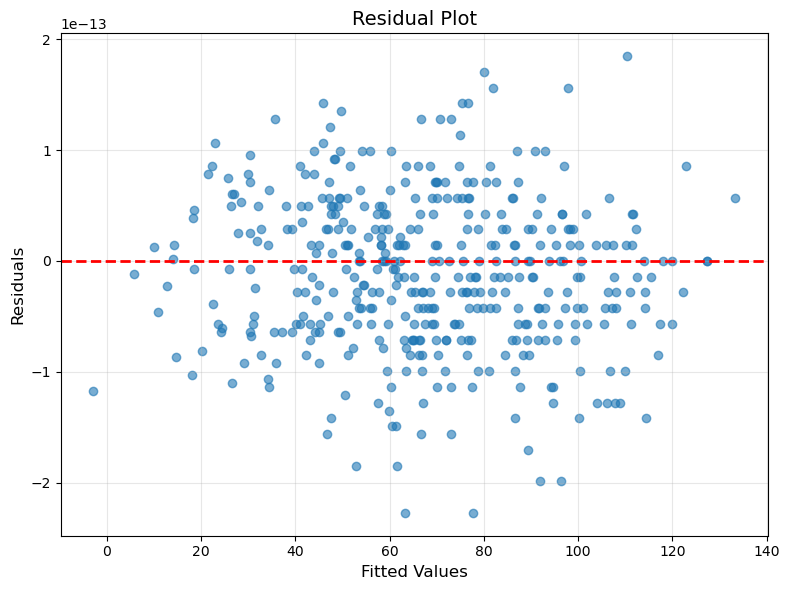

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

residuals = model.resid
ax.scatter(model.fittedvalues, residuals, alpha=0.6)
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)

ax.set_xlabel("Fitted Values", fontsize=12)
ax.set_ylabel("Residuals", fontsize=12)
ax.set_title("Residual Plot", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Part B**

In [ ]:
# calculating the standard deviation of residuals
residual_std = np.sqrt(model.mse_resid)
print(f"Standard deviation of residuals: {residual_std:.15f}") 
# the near zero RMSE suggest near perfect multicollinearity and overfitting. 

In [ ]:
# Calculate autocorrelations for lags 0-3
# Note: lag 0 is always 1 (correlation with itself)
autocorrelations = acf(model.resid, nlags=3)

print("Autocorrelations:")
for lag, acf_value in enumerate(autocorrelations):
    print(f"Lag {lag}: {acf_value:.4f}")

In [ ]:
# estimating parameters from residuals
residuals = model.resid
rho = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
sigma_squared = np.var(residuals, ddof=1)
n = len(y)

cov_matrix = sigma_squared * toeplitz(rho ** np.arange(n))

gls_model = sm.GLS(y, X, sigma=cov_matrix)
gls_results = gls_model.fit()

In [10]:
gls_model = sm.GLS(y, X).fit()
gls_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            GLS Regression Results                            
==============================================================================
Dep. Variable:          Dependent Var   R-squared:                       1.000
Model:                            GLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.578e+30
Date:                Sat, 18 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:34:03   Log-Likelihood:                 12180.
No. Observations:                 422   AIC:                        -2.433e+04
Df Residuals:                     406   BIC:                        -2.426e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  32.0000    6.3e-14   5.08e+14      0.000      32.000      32.000
Explanatory Var #1      1.3000   5.09e-16   2.56e+15      0.000       1.300       1.300
Explanatory Var #2      1.7000    3.7e-16    4.6e+15      0.000       1.700       1.700
Explanatory Var #3      6.2000   7.09e-15   8.74e+14      0.000       6.200       6.200
Explanatory Var #4      2.1000   4.37e-16   4.81e+15      0.000       2.100       2.100
Explanatory Var #5     -0.9000   5.12e-16  -1.76e+15      0.000      -0.900      -0.900
Explanatory Var #6  -3.636e-15   3.09e-16    -11.770      0.000   -4.24e-15   -3.03e-15
Explanatory Var #7  -8.674e-16   2.39e-16     -3.634      0.000   -1.34e-15   -3.98e-16
Explanatory Var #8  -5.218e-15   3.24e-15     -1.609      0.108   -1.16e-14    1.16e-15
Explanatory Var #9   3.187e-15   4.15e-16      7.685      0.000    2.37e-15       4e-15
Explanatory Var #10 -1.193e-15   5.17e-16     -2.309      0.021   -2.21e-15   -1.77e-16
Explanatory Var #11  3.962e-15      5e-16      7.927      0.000    2.98e-15    4.94e-15
Explanatory Var #12  5.829e-16   3.74e-16      1.559      0.120   -1.52e-16    1.32e-15
Explanatory Var #13  -2.62e-14   7.16e-15     -3.657      0.000   -4.03e-14   -1.21e-14
Explanatory Var #14  1.443e-15    4.4e-16      3.282      0.001    5.79e-16    2.31e-15
Explanatory Var #15 -1.721e-15   5.24e-16     -3.286      0.001   -2.75e-15   -6.91e-16
==============================================================================
Omnibus:                        0.895   Durbin-Watson:                   1.894
Prob(Omnibus):                  0.639   Jarque-Bera (JB):                0.773
Skew:                          -0.102   Prob(JB):                        0.680
Kurtosis:                       3.050   Cond. No.                     2.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""